1) Clearly Define the Problem
Many banks lose revenue due to customers leaving their services (called "churn"). Predicting churn using historical customer data enables proactive retention strategies.

📌 Objective: Build an ML model that predicts whether a customer will churn based on their demographic and account-related features.

2) EDA, Visualization, and Mathematical Basis
We will:

Clean and explore data (EDA).

Use matplotlib/seaborn for visualization.

Apply correlation metrics and statistical rules (e.g., chi-square for categorical vars, correlation for numeric).

Identify class imbalance, outliers, and feature importance.

3) Model Type & Justification
✅ Classification Problem
We're predicting Yes/No → whether a customer will churn → binary classification.

Why Classification?

Discrete output (0 = Not Churned, 1 = Churned).

Suitable for models like Logistic Regression, Decision Tree, Random Forest.

📉 Pros:

Easy to evaluate with accuracy, precision, recall.

Probabilistic prediction for business insight.

⚠️ Cons/Risks:

Imbalanced classes can mislead accuracy.

Overfitting with high-dimensional data.

4) Frameworks / Libraries
We’ll use:

pandas & numpy (data)

matplotlib, seaborn (EDA)

scikit-learn (modeling)

joblib (model persistence)



5) Python Code (EDA + Model Building)
⬇️ Download Sample Dataset

Here's a simplified yet balanced code walk-through:



In [ ]:
!pip install pandas scikit-learn matplotlib

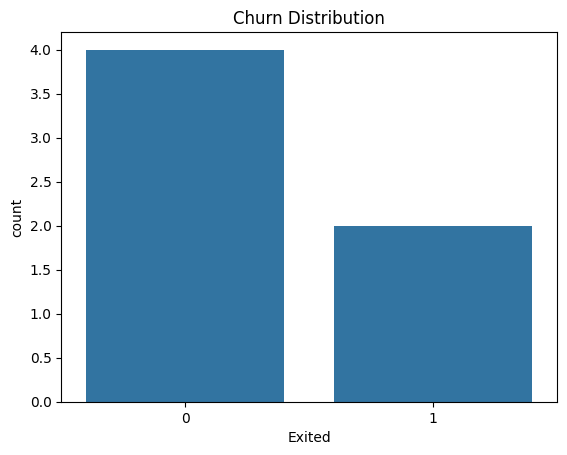

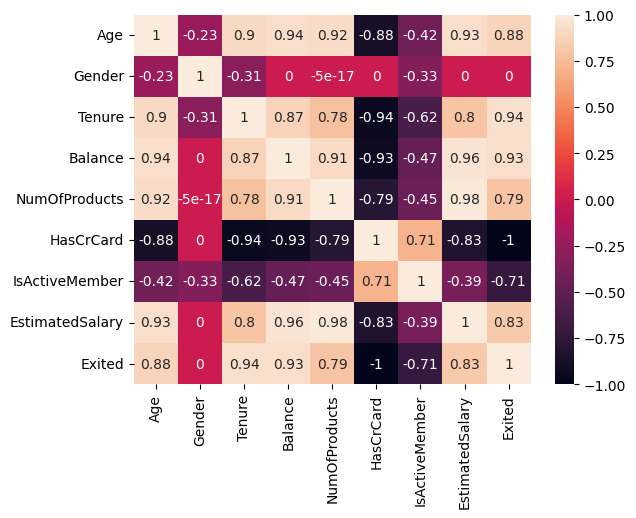

c:\Users\DELL\.virtualenvs\churn_prediction_bank-HBqykncv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\.virtualenvs\churn_prediction_bank-HBqykncv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\.virtualenvs\churn_prediction_bank-HBqykncv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

[[1 0]
 [1 0]]


['ml_models/churn_model.pkl']

In [ ]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 🔽 Load data
df = pd.read_csv(r'data/current_churn_data.csv')

# 🧹 Data Cleaning
df.drop('CustomerID', axis=1, inplace=True)

# 🔄 Encode categorical
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])  # Male=1, Female=0

# 📊 EDA
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution')
plt.show()

# 🔍 Correlation
sns.heatmap(df.corr(), annot=True)
plt.show()

# 🔢 Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(df.drop('Exited', axis=1))
y = df['Exited']

# ✂️ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 🧠 Model Building
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 📈 Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# 💾 Save model
joblib.dump(model, r'ml_models/churn_model.pkl')


7) Retraining Code

In [7]:
# Load and retrain with new data
new_data = pd.read_csv(r"data/new_churn_data.csv")
# Apply same preprocessing: encode, scale, etc.
# Then retrain:
model.fit(X_train, y_train)
joblib.dump(model, r'ml_models/new_churn_model.pkl')  # Overwrite old model


['ml_models/new_churn_model.pkl']

8) Things to Watch Out For
Data leakage (using future data in training)

Class imbalance (use SMOTE or class weights)

Overfitting (cross-validation, simpler models)

9) Deployment Steps
Use Flask or FastAPI to create an API.

Load model using joblib.load.

Deploy on Render, Heroku, or AWS.

In [9]:
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)
model = joblib.load(r"ml_models/churn_model.pkl")

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    # preprocess input like scaling, encoding
    pred = model.predict([data['features']])
    return jsonify({"prediction": int(pred[0])})

app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [03/May/2025 12:30:09] "POST /predict HTTP/1.1" 200 -


import requests

# Sample input features (after encoding & scaling in your backend)
data = {
    "features": [25, 1, 50000, 1, 1, 1, 40000, 1]  # Example input
}

response = requests.post("http://127.0.0.1:5000/predict", json=data)
print("Prediction:", response.json()["prediction"])
